Santiago Andrés Acosta Díaz

## 1. Open and close a .fits file

The first step in accessing the file is to open it using the `astropy.io.fits.open()` function. This function returns an object called **HDUList** (**H**eader **D**ata **U**nits **List**). Here we will call this object `hdul`.

__En mi caso, aquellas líneas que modifique respecto a las del profesor van a estar por encima de la línea original comentada. El sistema que elegí analizar es la nebulosa de Bola de Crystal MGC 1514, tomada de https://skyview.gsfc.nasa.gov/current/cgi/runquery.pl?float=on&Interface=quick&Position=NGC+1514+&SURVEY=Digitized+Sky+Survey__

PDT: estoy borrando todo lo que no incumbe en esta tarea para que sea más fácil de revisar.

In [21]:
from matplotlib import pyplot as plt
from astropy.io import fits
import numpy as np
%matplotlib inline

hdul = fits.open('CrystallBallNebula.fits')
# hdul = fits.open('HorseHead.fits')
hdul

The `.info()` method will return a summary of the contents of the FITS file,

In [22]:
hdul.info()

Filename: CrystallBallNebula.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     172   (300, 300)   float32   


In general, there can be several information units, denoted by the names `hdul[0]`, `hdul[1]`, etc. The `hdul[0]` drive is called the PRIMARY drive and usually contains the initial access information for the file (eg number of cards, dimensions, format, etc.). In the other units there is additional relevant information, such as masks, filters, etc.

After accessing this information, and if no other action is to be taken, it is advisable to close the file to avoid corrupting it,

In [23]:
hdul.close()

An efficient way to access the information, opening and closing the file automatically, is

In [25]:
with fits.open('CrystallBallNebula.fits') as hdul:
# with fits.open('HorseHead.fits') as hdul:
    hdul.info()

Filename: CrystallBallNebula.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     172   (300, 300)   float32   


### 1.1. Headers and Data (Headers and Data)

Each HDU object contains the `.header` and `.data` attributes. Using the `header` attribute it is possible to access the header of the HDU object, which contains all the information of this data unit,

In [26]:
hdul[0].header

SIMPLE  =                    T / Written by SkyView Mon Jun 01 11:28:13 EDT 2026
BITPIX  =                  -32 / 4 byte floating point                          
NAXIS   =                    2 / Two dimensional image                          
NAXIS1  =                  300 / Width of image                                 
NAXIS2  =                  300 / Height of image                                
CRVAL1  =    62.32077300000001 / Reference longitude                            
CRVAL2  =   30.775964000000005 / Reference latitude                             
RADESYS = 'FK5     '           / Coordinate system                              
EQUINOX =               2000.0 / Epoch of the equinox                           
CTYPE1  = 'RA---TAN'           / Coordinates -- projection                      
CTYPE2  = 'DEC--TAN'           / Coordinates -- projection                      
CRPIX1  =                150.5 / X reference pixel                              
CRPIX2  =                150

Here you will find a lot of information, such as: ORIGIN, DATE, RA, DEC, TELESCOPE, FILTER, etc. To access each of them you can use

__En este caso, la metadata de este FITS no está formateada de la misma manera que el archivo del profesor, entonces me tocó hacer apaños__

In [78]:
# Aquí vamos a filtrar el telescopio
for line in hdul[0].header['COMMENT']:
    if "TELES" in line:
        print(line)

# hdul[0].header['FILTER']

TELESCOP= 'UK Schmidt (new optics)' /Telescope where plate taken
TELESCOP= 'Palomar 48-inch Schmidt' /Telescope where plate taken


---

On the other hand, the `data` attribute gives access to the information stored in the HDU. For example, in the specific case we are working on, we will assign this information to the image_data variable.

**Note: It is important to assign this information before closing the file!**

In [79]:
hdul = fits.open('CrystallBallNebula.fits')
image_data = hdul[0].data
hdul.close()

The information has been saved as a NumPy array,

In [80]:
type(image_data)

numpy.ndarray

In [81]:
image_data.shape

(300, 300)

In this way we can easily access the data,

In [82]:
image_data[10:15 , 20:30]

array([[3230., 3377., 3671., 3524., 3524., 3671., 3377., 4700., 5876.,
        4700.],
       [3230., 3377., 3671., 3524., 3524., 3377., 3671., 4406., 4994.,
        4406.],
       [3450., 3450., 3450., 3450., 3450., 3597., 3597., 3891., 3891.,
        3744.],
       [3450., 3450., 3450., 3450., 3450., 3597., 3597., 3597., 3597.,
        3744.],
       [3450., 3597., 3303., 3450., 3450., 3303., 3597., 3450., 3450.,
        3450.]], dtype='>f4')

We can also obtain important statistical information,

In [83]:
np.min(image_data)

np.float32(2542.0)

In [84]:
np.max(image_data)

np.float32(14587.0)

In [85]:
np.mean(image_data)

np.float32(3851.4458)

## 2. Image Display

For the file we are considering, the information stored corresponds to a photometric image of the nebula. In this way, we can use a function like [matplotlib.pyplot.imshow()](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.imshow.html) to display the image

http://learn.astropy.org/rst-tutorials/FITS-images.html?highlight=filtertutorials

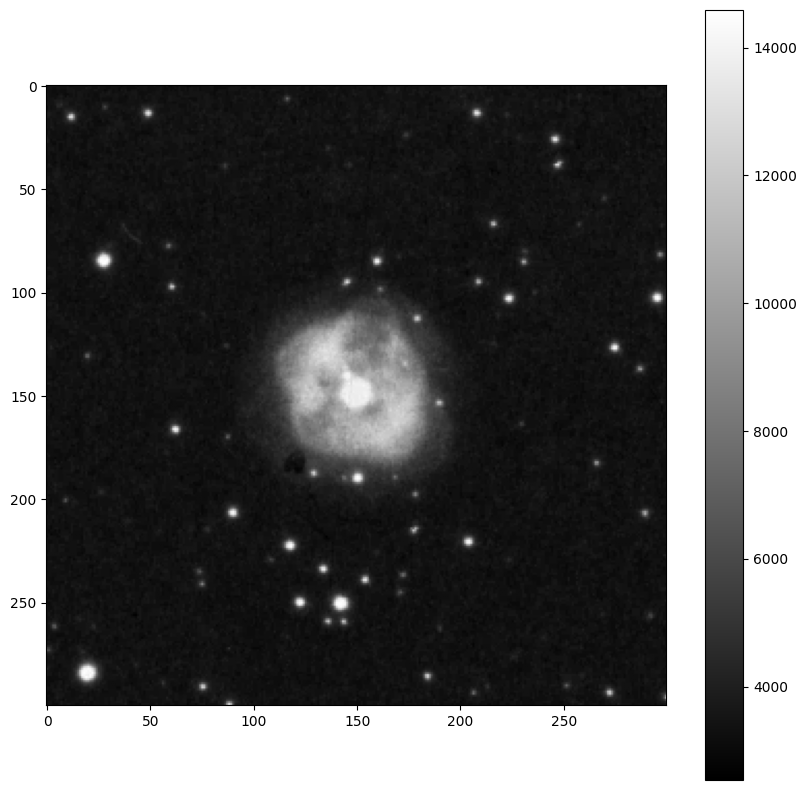

In [86]:
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='gray')
plt.colorbar()
plt.show()

The 'gray' color map can be changed. [There are multiple options](https://matplotlib.org/3.1.1/tutorials/colors/colormaps.html)

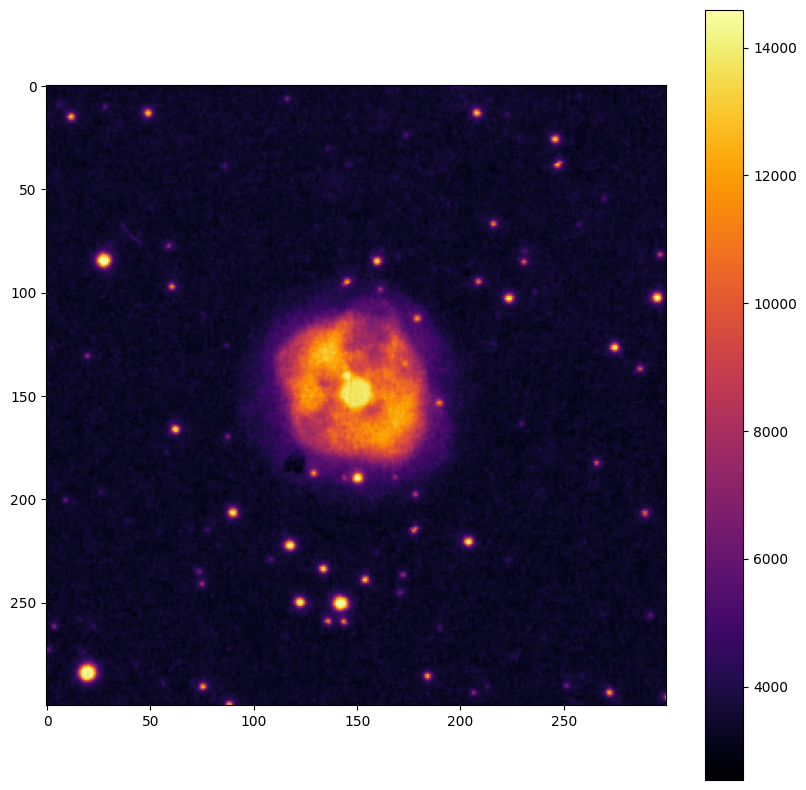

In [87]:
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='inferno')
plt.colorbar()
plt.show()

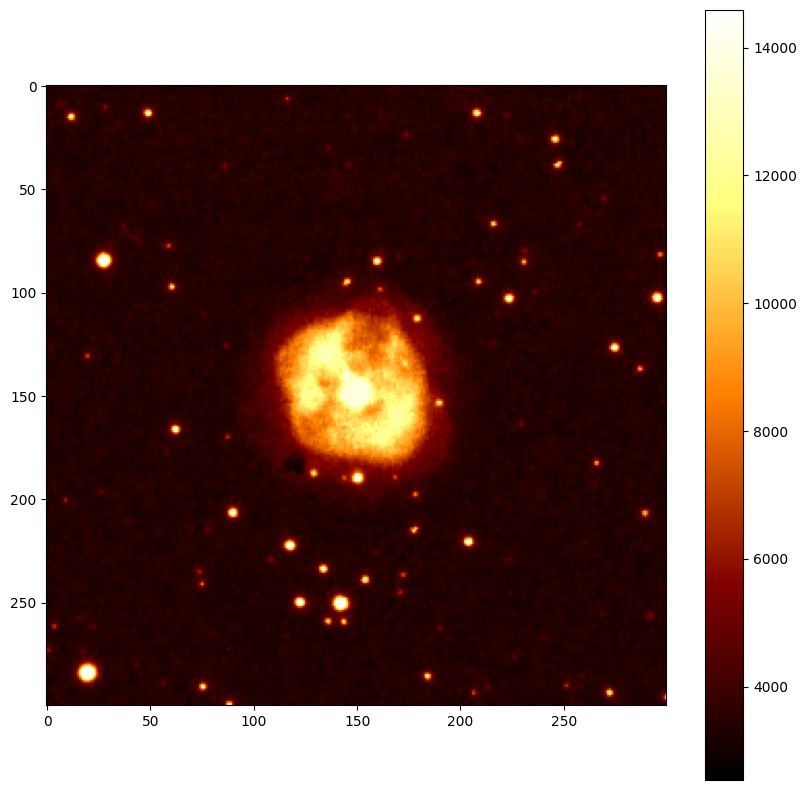

In [88]:
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='afmhot')
plt.colorbar()
plt.show()

Additionally, a logarithmic color scale can be used to highlight details using the [matplotlib.colors.LogNorm](https://matplotlib.org/3.5.0/api/_as_gen/matplotlib.colors.LogNorm.html) function.

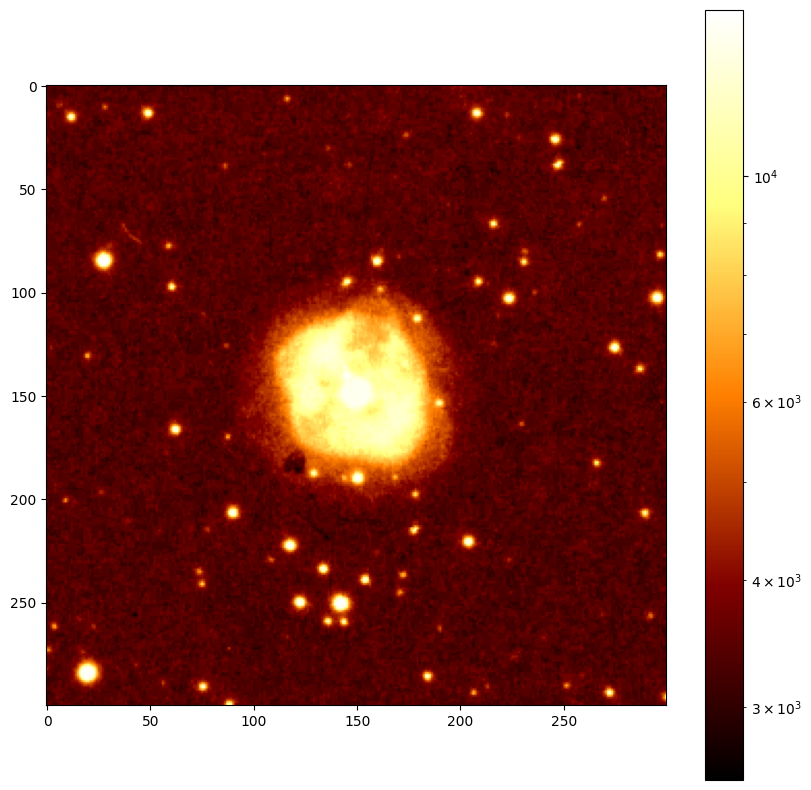

In [89]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='afmhot', norm=LogNorm())
plt.colorbar()
plt.show()

### 2.1. Histogram
The data in the 2D array can be flattened,

In [90]:
flat_data = image_data.flatten()

and with this a histogram can be built to visualize what values (colors) appear within the image [matplotlib.pyplot.hist()](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.hist.html)

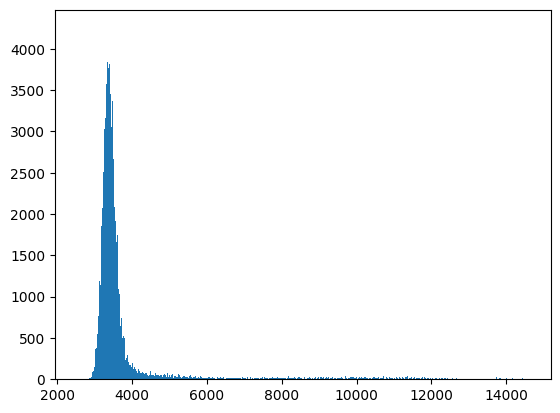

In [91]:
plt.figure()
plt.hist(flat_data, bins='auto') 
plt.show()

With this information it is possible to redisplay the image by removing some of the points in order to enhance details and improve the image

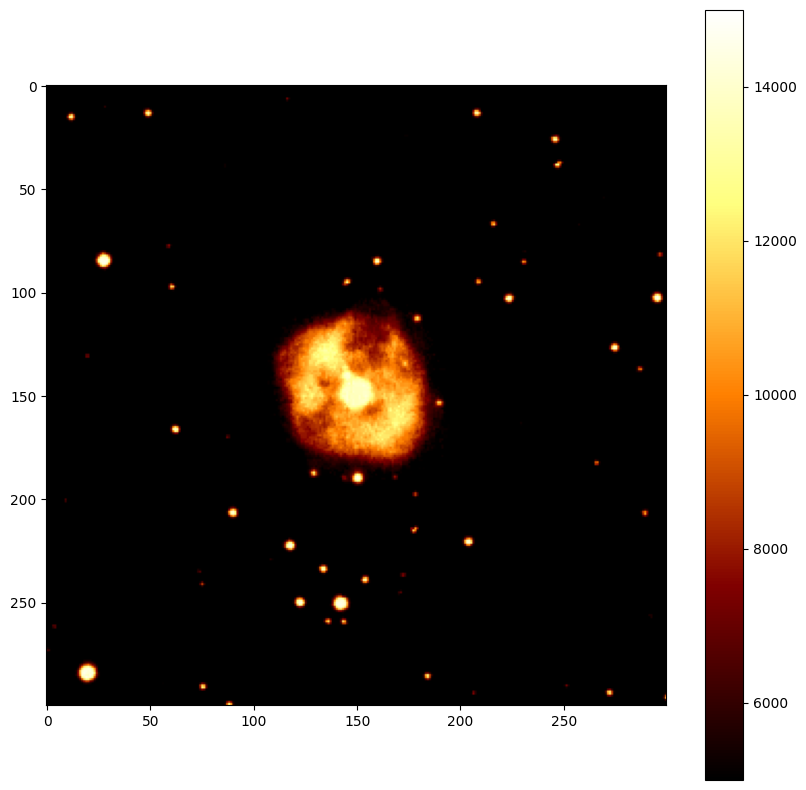

In [92]:
plt.figure(figsize=(10,10))
plt.imshow(image_data, cmap='afmhot', vmin=5E3, vmax=1.5E4)
plt.colorbar()
plt.show()